<a href="https://colab.research.google.com/github/silviasd2025-bit/dea_studies/blob/main/20260114_dea_dim_imp_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This Jupiter DEA computes DEA VRS / CRS with configurable inputs/output

In [1]:
import subprocess
subprocess.check_call(['pip', 'install', 'pulp'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

0

In [2]:
from datetime import datetime
import os
import pulp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# The core DEA class, setting up and solving the linear programming
# problems using PuLP.



class DEAProblem:

    """
    A container for the elements of a data envelopment analysis problem. Sets
    up the linear programmes and solves them with pulp.

    Requires:

        inputs: a pandas dataframe of the inputs to the DMUs
        outputs: a pandas dataframe of the outputs from the DMUs
        kind: 'VRS' or 'CRS'
        in_weights: the weight restriction to apply to all inputs to all DMUs
                    (default is [0, inf])
        out_weights: the weight restriction to apply to all outputs to all DMUs
                     (default is [0, inf)

    Weight restrictions must be specified as a list. To specify only one bound
    leave the other as None, eg. in_weights=[1, None].

    """

    def __init__(self, inputs, outputs, returns='CRS',
                 in_weights=[0, None], out_weights=[0, None]):
        """
        Set up the DMUs' problems, ready to solve.

        """
        self.inputs = _to_dataframe(inputs)
        self.outputs = _to_dataframe(outputs)
        self.returns = returns

        self.J, self.I = self.inputs.shape  # no of firms, inputs
        _, self.R = self.outputs.shape  # no of outputs
        self._i = range(self.I)  # inputs
        self._r = range(self.R)  # outputs
        self._j = range(self.J)  # DMUs

        self._in_weights = in_weights  # input weight restrictions
        self._out_weights = out_weights  # output weight restrictions

        # creates dictionary of pulp.LpProblem objects for the DMUs
        self.dmus = self._create_problems()

    def _create_problems(self):
        """
        Iterate over the inputs and create a dictionary of LP problems, one
        for each DMU.

        """

        dmu_dict = {}
        for j0 in self._j:
            dmu_dict[j0] = self._make_problem(j0)
        return dmu_dict

    def _make_problem(self, j0):
        """
        Create a pulp.LpProblem for a DMU.

        """

        # Set up pulp
        prob = pulp.LpProblem("".join(["DMU_", str(j0)]), pulp.LpMaximize)
        self.inputWeights = pulp.LpVariable.dicts("inputWeight", (self._j, self._i),
                                                  lowBound=self._in_weights[0], upBound=self._in_weights[1])
        self.outputWeights = pulp.LpVariable.dicts("outputWeight", (self._j, self._r),
                                                   lowBound=self._out_weights[0], upBound=self._out_weights[1])

        # Set returns to scale
        if self.returns == "CRS":
            w = 0
        elif self.returns == "VRS":
            w = pulp.LpVariable.dicts("w", (self._j, self._r))
        else:
            raise Exception(ValueError)

        # Set up objective function
        prob += pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j0][r1]) for r1 in self._r]) - w

        # Set up constraints
        prob += pulp.LpAffineExpression([(self.inputWeights[j0][i1],
                                          self.inputs.values[j0][i1]) for i1 in self._i]) == 1, "Norm_constraint"
        for j1 in self._j:
            prob += self._dmu_constraint(j0, j1) - \
                w <= 0, "".join(["DMU_constraint_", str(j1)])
        return prob

    def _dmu_constraint(self, j0, j1):
        """
        Calculate and return the DMU constraint for a single DMU's LP problem.

        """

        eOut = pulp.LpAffineExpression(
            [(self.outputWeights[j0][r1], self.outputs.values[j1][r1]) for r1 in self._r])
        eIn = pulp.LpAffineExpression(
            [(self.inputWeights[j0][i1], self.inputs.values[j1][i1]) for i1 in self._i])
        return eOut - eIn

    def _solver(self):
        """
        Iterate over the dictionary of DMUs' problems, solve them, and collate
        the results into a pandas dataframe.

        """

        sol_status = {}
        sol_weights = {}
        sol_efficiency = {}

        for ind, problem in list(self.dmus.items()):
            problem.solve()
            sol_status[ind] = pulp.LpStatus[problem.status]
            sol_weights[ind] = {}
            for v in problem.variables():
                sol_weights[ind][v.name] = v.varValue
            sol_efficiency[ind] = pulp.value(problem.objective)
        return sol_status, sol_efficiency, sol_weights

    def _build_weight_results_dict(self, sol_weights):
        """
        Rename weights from input and output column names, then build a
        pandas dataframe of all weights.

        """
        import re
        tmp_dict = {}
        for dmu, d in list(sol_weights.items()):
            tmp_dict[dmu] = {}
            for key, _ in list(d.items()):
                m = re.search(r'[0-9]+$',key)
                i = int(m.group(0))
                if key.startswith("input"):
                    tmp_dict[dmu]["in_" + str(self.inputs.columns[i])] = d[key]
                if key.startswith("output"):
                    tmp_dict[dmu][
                        "out_" + str(self.outputs.columns[i])] = d[key]
        weight_results = pd.DataFrame.from_dict(tmp_dict).T

        return weight_results

    def solve(self, sol_type='technical'):
        """"
        Solve the problem and create attributes to hold the solutions.

        Takes:
            sol_type: 'technical'/'allocative'/'economic'
            dmus: tuple defining range of DMUs to solve for.

        """

        if sol_type == 'technical':
            sol_status, sol_efficiency, sol_weights = self._solver()
            weight_results = self._build_weight_results_dict(sol_weights)
            status_df = pd.Series(sol_status, name='Status')
            status_df.index = self.inputs.index
            efficiency_df = pd.Series(sol_efficiency, name='Efficiency')
            efficiency_df.index = self.inputs.index

            return DEAResults((('Status', status_df),
                               ('Efficiency', efficiency_df),
                               ('Weights', weight_results)))
        else:
            print("Solution type not yet implemented.")
            print("Solving for technical efficiency instead.")
            self.solve()


class DEAResults(dict):

    """
    A class to hold the results of a DEAProblem and provide methods for
    their examination. Essentially a dictionary of pandas Series with
    methods for conducting particular operations on DEA results.

    """

#    def __init__(self):
#        super(DEAResults, self).__init__()
#        pass

    def find_comparators(self, dmu):
        """
        Return the DMUs that form the frontier for the specified DMU.

        """
        pass

    def env_corr(self, env_vars, qq_plot=False):
        """
        Determine correlations with environmental/non-discretionary variables
        using a logit regression. Tobit will be implemented when available
        upstream in statsmodels.

        Takes:
            env_vars: A pandas dataframe of environmental variables

        Returns:
            corr_mod: the statsmodels' model instance containing the inputs
                      and results from the logit model.

        Note that there can be no spaces in the variables' names.
        """

        import matplotlib.pyplot as plt
        from statsmodels.regression.linear_model import OLS
        from statsmodels.graphics.gofplots import qqplot

        env_data = _to_dataframe(env_vars)
        corr_data = env_data.join(self['Efficiency'])
        corr_mod = OLS.from_formula(
            "Efficiency ~ " + " + ".join(env_vars.columns), corr_data)
        corr_res = corr_mod.fit()

        #plot qq of residuals
        if qq_plot:
            qqplot(corr_res.resid, line='s')
            plt.title('Distribution of residuals')

        print(corr_res.summary())

        return corr_res


def _to_dataframe(indata):
    """
    Indexers require input to be a dataframe but the user may pass a
    series. Check and cast series to dataframes.

    """

    if type(indata) == pd.core.frame.DataFrame:
        return indata
    elif type(indata) == pd.core.series.Series:
        return pd.DataFrame(indata, columns=['input_data'])
    else:
        raise TypeError(
            "Input data is not a valid pandas DataFrame or Series.")


In [4]:
# DEA accepts : 'VRS' or 'CRS'

# Load data
df_read_old = pd.read_csv("/content/drive/MyDrive/data/20251202_owid-energy-dataDEAMPIEnergySecurityEvaluationG20.csv")
df_read_new = pd.read_csv("/content/drive/MyDrive/data/owid-energy-data G20.csv")


# Print the shape
print(df_read_new.shape)

df_new = df_read_new
df_old = df_read_old

print ("New table")
print ("==========")
print(df_new.shape)
print(df_new.columns.tolist())
list_of_variables_new_table = df_new.columns.tolist()
for elem in list_of_variables_new_table:
  print("variable(new table):", elem)

print ("Old table")
print ("==========")
print(df_old.shape)
print(df_old.columns.tolist())

list_of_variables_old_table = df_old.columns.tolist()
for elem in list_of_variables_old_table:
  print("variable(old table):", elem)

# Change name of columns 'dmu' is needed
df_new.rename(columns = {'country':'dmu'}, inplace = True)
df_old.rename(columns = {'country':'dmu'}, inplace = True)

# Replace dmu 'European Union'  by EU27
df_new['dmu'] = df_new['dmu'].replace('European Union (27)', 'EU27')
df_old['dmu'] = df_old['dmu'].replace('European Union (27)', 'EU27')

alpha_coal = 0.85
alpha_gas  = 0.90
alpha_oil  = 0.90
alpha_nuclear = 0.90
alpha_biofuel = 0.9
alpha_hydro = 0.75
alpha_solar = 0.25
alpha_wind_onshore = 0.20
alpha_wind_offshore =0.25
alpha_wind = 0.20


# Computations with columns

df_new['hhi'] = (df_new['biofuel_share_energy']**2 + df_new['coal_share_energy']**2 + df_new['gas_share_energy']**2\
             + df_new['hydro_share_energy']**2 + df_new['nuclear_share_energy']**2 + df_new['oil_share_energy']**2\
             + df_new['solar_share_energy']**2 + df_new['wind_share_energy']**2 + df_new['other_renewables_share_energy']**2)

df_new['inv_hhi'] = 1 / df_new['hhi']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports']
#df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)
df_new['gdp_per_capita'] = df_new['gdp'] / df_new['population']

df_new['net_elec_imports_positive'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_imports_positive'] = df_new['net_elec_imports_positive'].where(df_new['net_elec_imports_positive'] >= 0, 0)

df_new['net_elec_export'] = df_new['net_elec_imports_share_demand']
df_new['net_elec_export'] = -df_new['net_elec_export'].where(df_new['net_elec_export'] <= 0, 0)

df_new['firm_capacity_factor'] = df_new['biofuel_elec_per_capita']/alpha_biofuel + df_new['coal_elec_per_capita']/alpha_coal\
    + df_new['gas_elec_per_capita'] / alpha_gas + df_new['hydro_elec_per_capita'] / alpha_hydro + df_new['nuclear_elec_per_capita']/alpha_nuclear\
     + df_new['oil_elec_per_capita']/ alpha_oil + df_new['solar_elec_per_capita']/ alpha_solar + df_new['wind_elec_per_capita']/  alpha_wind



df_old['net_elec_imports_positive'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_imports_positive'] = df_old['net_elec_imports_positive'].where(df_old['net_elec_imports_positive'] >= 0, 0)

df_old['net_elec_export'] = df_old['net_elec_imports_share_demand']
df_old['net_elec_export'] = -df_old['net_elec_export'].where(df_old['net_elec_export'] <= 0, 0)

# Print the shape

print(df_new.shape)
countries = list(df_new['dmu'].unique())
years     = list(df_new['year'].unique())
print ('countries:', countries)
print(len(countries))

print('years:', years)
print(len(years))


list_of_variables = df_new.columns.tolist()
for elem in list_of_variables:
  print(elem)

# Create results DataFrame

df_tmp = df_new[df_new['year'] == 2000]
results = pd.DataFrame({
     'DMU': df_tmp['dmu'],
    })
l_results = []

input_cols_old = ['energy_per_capita',
                  'carbon_intensity_elec',
                  #'I3-Energy import',
                  'net_elec_imports_positive'
                  ]
output_cols_old = [
               #'Energy export',
               #'net_elec_export'
               #'MWh_capita',
               'gdp_capita',
               'per_capita_electricity'
              ]

input_cols_new = ['energy_per_capita',
              'carbon_intensity_elec',
              'net_elec_imports_positive',
              ]
output_cols_new = [ 'gdp_per_capita',
               'per_capita_electricity'
               ]

#parameter
old = True
normalize = True
if old == True:
  input_cols = input_cols_old
  output_cols = output_cols_old
else:
  input_cols = input_cols_new
  output_cols = output_cols_new


variables2plot = input_cols + output_cols
year_start = 2000
year_end   = 2024
method_ret = "CRS"



(500, 130)
New table
(500, 130)
['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_demand_per_capita', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', '

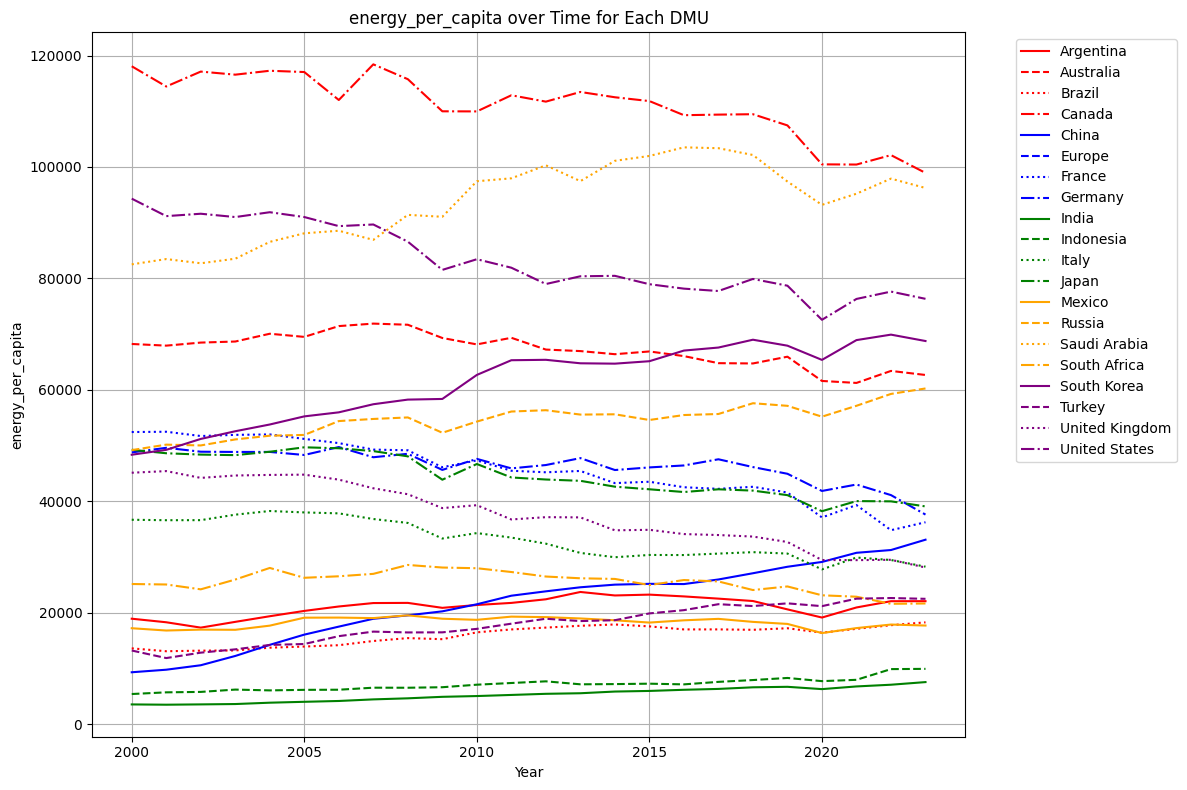

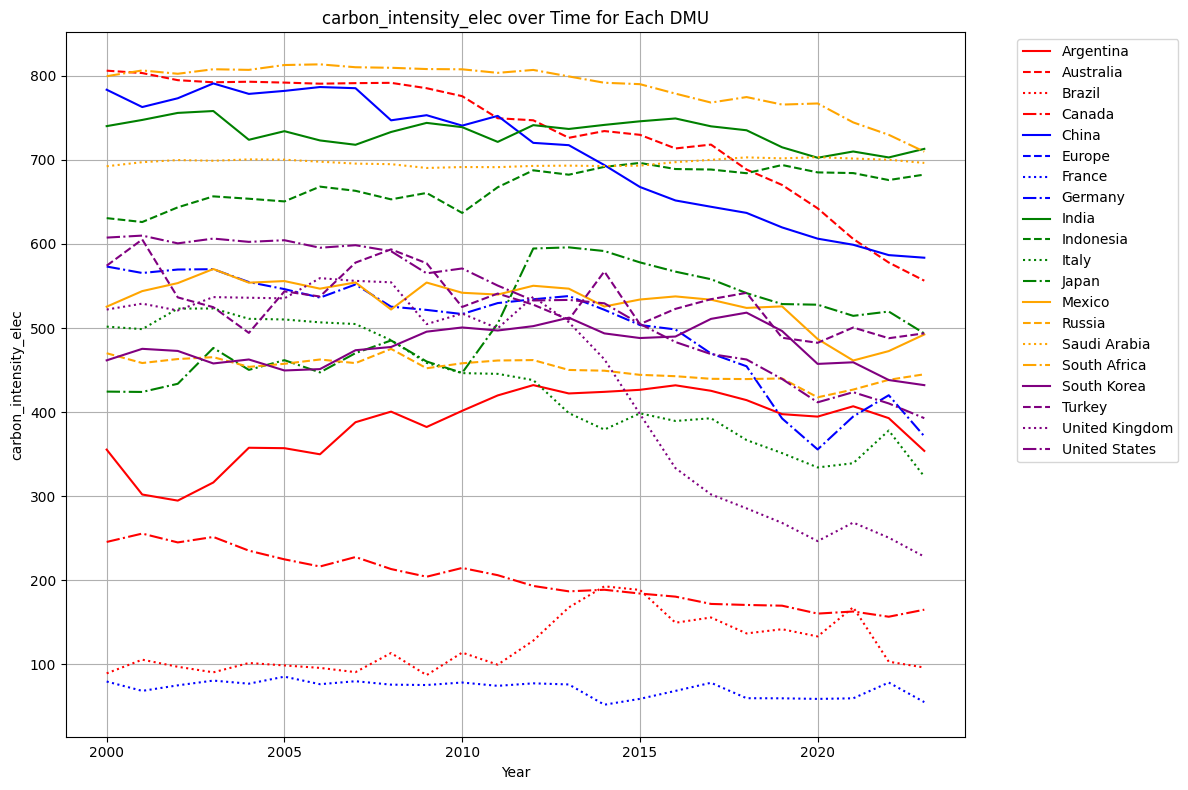

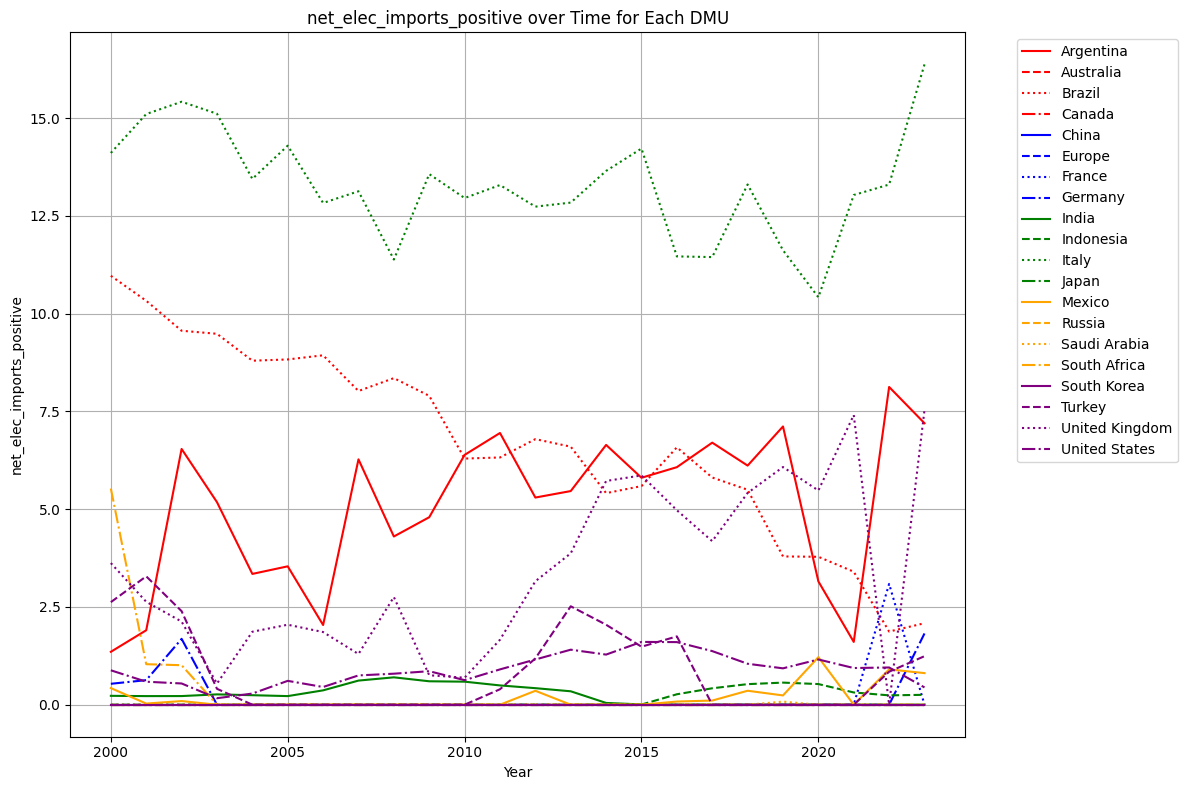

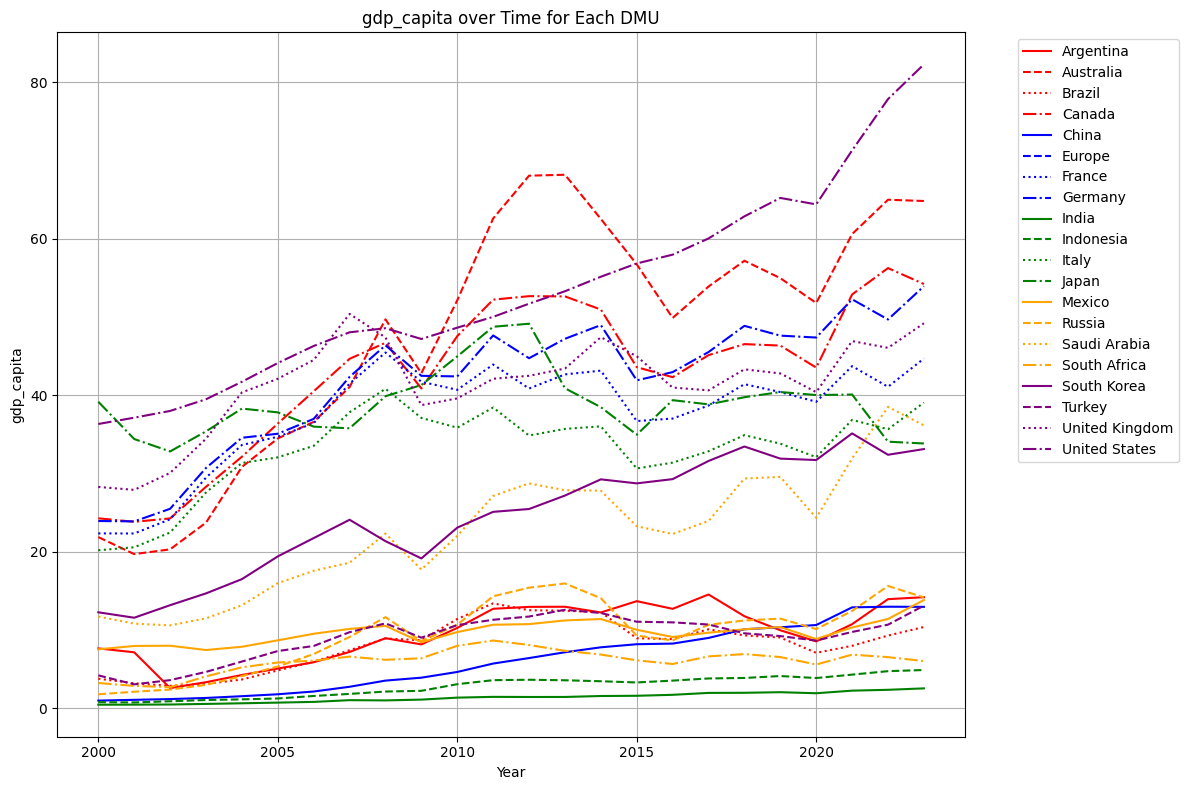

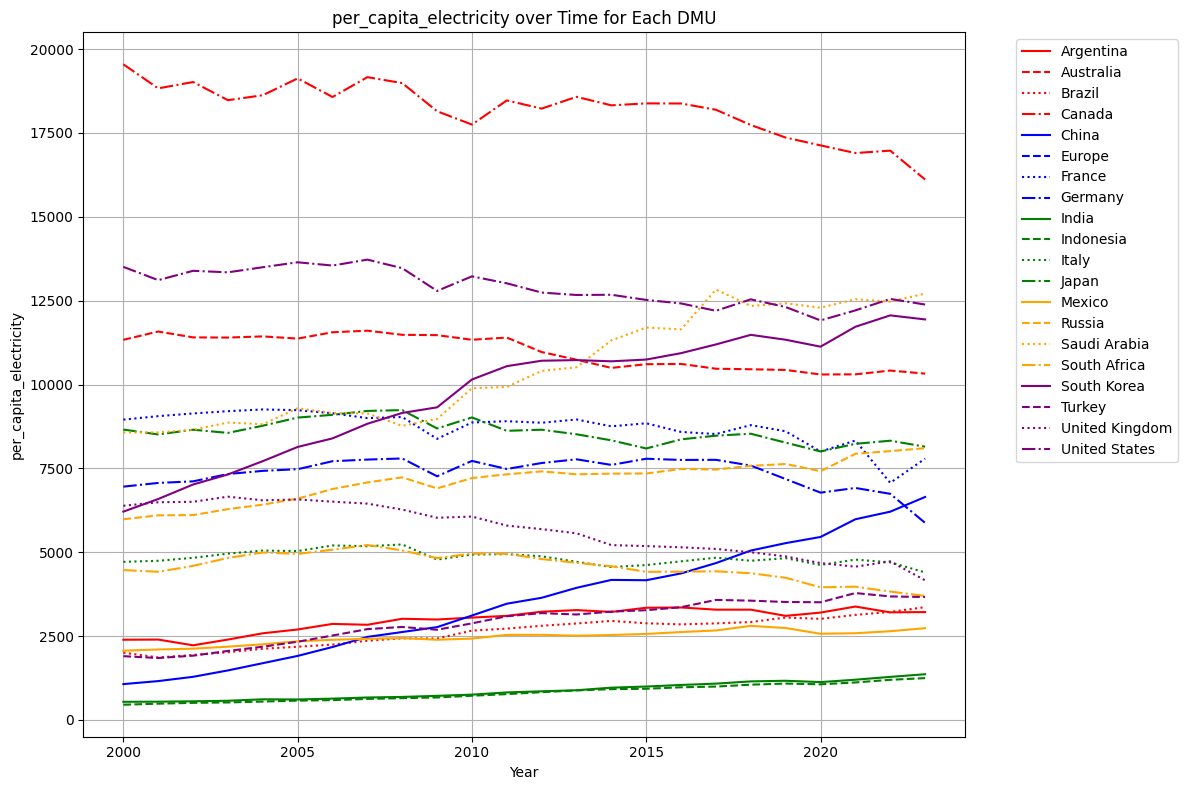

In [5]:
import itertools

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(countries)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

# Determine which DataFrame is currently active for plotting based on the 'old' flag.
# This part assumes 'old' variable is correctly set in previous cells.
active_df_for_plotting = df_old if old else df_new

for variable in variables2plot:
    # Create a cycle of unique (color, style) combinations
    style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)

    plt.figure(figsize=(12, 8))
    for dmu in countries:
      # 'data' will be filtered from 'active_df_for_plotting'
      if old:
        data = df_old[df_old["dmu"] == dmu]
      else:
        data = df_new[df_new["dmu"] == dmu]

      # The variable should already be in 'variables_to_iterate' and checked for existence
      # in 'active_df_for_plotting', so direct access should be safe here.

      color, style = next(style_cycle)
      plt.plot(
            data["year"],
            data[variable],
            label=dmu,
            color=color,
            linestyle = style
        )

    plt.xlabel("Year")
    plt.ylabel(variable)
    plt.title(f"{variable} over Time for Each DMU")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def normalize_data(data):
    """
    Normalize data using robust scaling
    """

    # Calculate min and max values for each column
    min_vals = np.min(data, axis=0)

    max_vals = np.max(data, axis=0)
    range_vals = max_vals - min_vals

    # Replace 0 values with 1 to avoid division by zero DOES NOT WORK so commment 2026/01/21
    #range_vals[range_vals == 0] = 1

    # Scale to [0.1, 1] range
    normalized = 0.1 + 0.9 * (data - min_vals) / range_vals

    return normalized

In [7]:
dir2write = datetime.now().strftime("/content/drive/MyDrive/out/%Y%m%d%H%M%S"+ method_ret)
os.mkdir(dir2write )

for year in range(year_start, year_end):
  print("------------\n\n)")
  print ("year:", year)
  print("------------\n\n)")
  if old:
    df_year     = df_old[df_old['year'] == year]
  else:
    df_year     = df_new[df_new['year'] == year]

  inputs_dea = df_year[input_cols]
  outputs_dea = df_year[output_cols]

  print("------------\n\n)")
  print ("Inputs :")
  print("------------\n\n)")
  print (inputs_dea)

  print("------------\n\n")
  print ("Outputs :")
  print("------------\n\n")
  print (outputs_dea)

  if normalize == True:
    for variable in input_cols:
      print ('variable', variable)
      print(inputs_dea[variable])
      inputs_dea[variable] = normalize_data(inputs_dea[variable])

    for variable in output_cols:
      print ('variable', variable)
      print(outputs_dea[variable])
      outputs_dea[variable] = normalize_data(outputs_dea[variable])

    print("------------\n\n")
    print ("Inputs Normalized:")
    print("------------\n\n")
    print (inputs_dea)

    print("------------\n\n")
    print ("Outputs :")
    print("------------\n\n")
    print (outputs_dea)



  prob = DEAProblem(inputs_dea, outputs_dea, returns=method_ret)
  myresults = prob.solve()

  print ('----------------\n\n\n')
  print ('*** Status ***')
  print ('----------------\n\n\n')
  print (myresults['Status'])

  print ('----------------\n\n\n')
  print ('*** Efficiency ***')
  print ('----------------\n\n\n')
  print (myresults['Efficiency'])
  l_results.append(myresults['Efficiency'])
  results[year] = myresults['Efficiency'].values

  print ('----------------\n\n\n')
  print ('----------------\n\n\n')
  print('*** Weights ***')
  print('----------------\n\n\n')

  print (type(myresults['Weights']))
  print (myresults['Weights'])


  print (results[year])
  with pd.ExcelWriter(os.path.join(dir2write,"dea_out_"+ str(year)  + '.xlsx')) as writer:
              inputs_dea.to_excel(writer, sheet_name='Inputs')
              outputs_dea.to_excel(writer, sheet_name='Outputs')
              myresults['Status'].to_excel(writer, sheet_name='Status')
              myresults['Efficiency'].to_excel(writer, sheet_name='Efficiency')
              myresults['Weights'].to_excel(writer, sheet_name='Weights')

  if  os.path.exists(os.path.join(dir2write, "dea_efficiency.xlsx")):
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))
  else:
    with pd.ExcelWriter(os.path.join(dir2write, "dea_efficiency.xlsx"), mode='w') as writer2eff:
                     myresults['Efficiency'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_weights.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_weights.xlsx"), mode='w') as writer2eff:
                     myresults['Weights'].to_excel(writer2eff, sheet_name=str(year))

  if os.path.exists(os.path.join(dir2write, "dea_status.xlsx")):
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='a', if_sheet_exists='replace') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))
  else:
              with pd.ExcelWriter(os.path.join(dir2write, "dea_status.xlsx"), mode='w') as writer2eff:
                     myresults['Status'].to_excel(writer2eff, sheet_name=str(year))

------------

)
year: 2000
------------

)
------------

)
Inputs :
------------

)
     energy_per_capita  carbon_intensity_elec  net_elec_imports_positive
0            18907.830                355.473                      1.353
24           68222.375                805.977                      0.000
48           13586.250                 89.445                     10.969
72          118073.234                245.686                      0.000
96            9294.628                783.314                      0.000
120          42152.680                419.096                      0.336
144          52416.219                 79.766                      0.000
168          48756.914                573.126                      0.535
192           3521.430                740.037                      0.227
216           5387.870                630.661                      0.000
240          36668.434                501.667                     14.111
264          49228.012                42

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



0      Optimal
24     Optimal
48     Optimal
72     Optimal
96     Optimal
120    Optimal
144    Optimal
168    Optimal
192    Optimal
216    Optimal
240    Optimal
264    Optimal
288    Optimal
312    Optimal
336    Optimal
360    Optimal
384    Optimal
408    Optimal
432    Optimal
456    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



0      0.814034
24     0.975376
48     0.924602
72     1.000000
96     0.833833
120    0.858974
144    1.000000
168    0.841517
192    0.974890
216    0.818627
240    0.786101
264    1.000000
288    0.797608
312    0.741716
336    0.656891
360    1.000000
384    0.774787
408    0.895245
432    0.838498
456    0.840836
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.487786             

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



1      Optimal
25     Optimal
49     Optimal
73     Optimal
97     Optimal
121    Optimal
145    Optimal
169    Optimal
193    Optimal
217    Optimal
241    Optimal
265    Optimal
289    Optimal
313    Optimal
337    Optimal
361    Optimal
385    Optimal
409    Optimal
433    Optimal
457    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



1      0.830187
25     1.000000
49     0.893549
73     1.000000
97     0.828577
121    0.867036
145    1.000000
169    0.841431
193    0.967797
217    0.797317
241    0.804466
265    1.000000
289    0.812510
313    0.742285
337    0.650966
361    1.000000
385    0.801078
409    0.934133
433    0.878066
457    0.857263
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.528155             

...

----------------



*** Status ***
----------------



21     Optimal
45     Optimal
69     Optimal
93     Optimal
117    Optimal
141    Optimal
165    Optimal
189    Optimal
213    Optimal
237    Optimal
261    Optimal
285    Optimal
309    Optimal
333    Optimal
357    Optimal
381    Optimal
405    Optimal
429    Optimal
453    Optimal
477    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



21     0.782808
45     1.000000
69     0.870042
93     1.000000
117    0.922146
141    0.906541
165    1.000000
189    1.000000
213    0.844788
237    0.727851
261    0.901896
285    0.978273
309    0.739222
333    0.747515
357    0.784284
381    0.832930
405    0.942037
429    0.809262
453    1.000000
477    0.853924
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.233854             

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



22     Optimal
46     Optimal
70     Optimal
94     Optimal
118    Optimal
142    Optimal
166    Optimal
190    Optimal
214    Optimal
238    Optimal
262    Optimal
286    Optimal
310    Optimal
334    Optimal
358    Optimal
382    Optimal
406    Optimal
430    Optimal
454    Optimal
478    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



22     0.729939
46     1.000000
70     0.886494
94     1.000000
118    0.953392
142    0.940810
166    1.000000
190    0.982761
214    0.853468
238    0.658474
262    0.893894
286    1.000000
310    0.744336
334    0.741244
358    0.768901
382    0.855503
406    0.967239
430    0.794403
454    1.000000
478    0.969692
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.133272             

/tmp/ipython-input-875702224.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inputs_dea[variable] = normalize_data(inputs_dea[variable])
/tmp/ipython-input-875702224.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outputs_dea[variable] = normalize_data(outputs_dea[variable])


----------------



*** Status ***
----------------



23     Optimal
47     Optimal
71     Optimal
95     Optimal
119    Optimal
143    Optimal
167    Optimal
191    Optimal
215    Optimal
239    Optimal
263    Optimal
287    Optimal
311    Optimal
335    Optimal
359    Optimal
383    Optimal
407    Optimal
431    Optimal
455    Optimal
479    Optimal
Name: Status, dtype: object
----------------



*** Efficiency ***
----------------



23     0.695378
47     1.000000
71     0.855377
95     1.000000
119    0.935990
143    0.964716
167    1.000000
191    1.000000
215    0.824558
239    0.649548
263    0.905433
287    0.997584
311    0.742953
335    0.747313
359    0.811838
383    0.800870
407    0.986672
431    0.768415
455    1.000000
479    1.000000
Name: Efficiency, dtype: float64
----------------



----------------



*** Weights ***
----------------



<class 'pandas.core.frame.DataFrame'>
    in_energy_per_capita  in_carbon_intensity_elec  \
0               4.115046             

# New Section

In [8]:
results.head(20)
results.to_excel(os.path.join(dir2write,"dea_results.xlsx"))

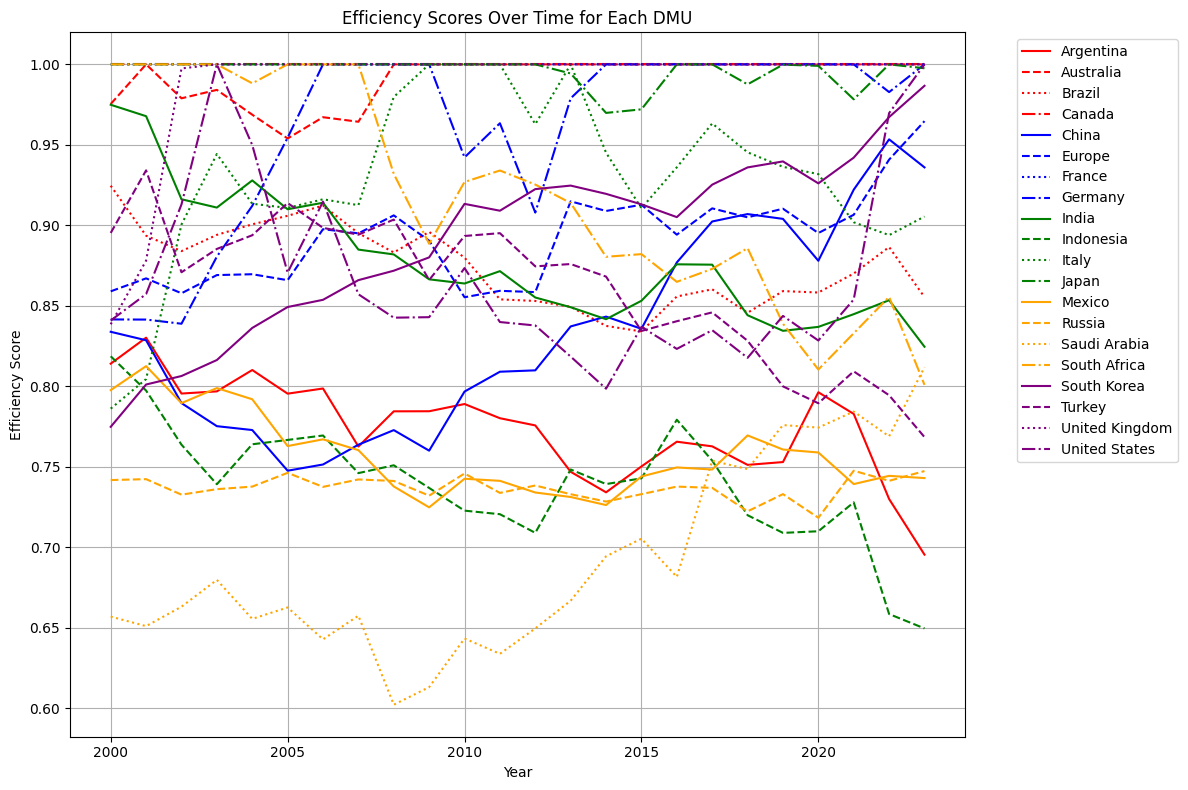

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import matplotlib.pyplot as plt

# Create a list of unique colors equal to the number of DMUs
num_dmus = len(results)
colors = plt.cm.tab20(np.linspace(0, 1, num_dmus))
color_list = [
    'red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan', 'magenta',
    'teal', 'gold', 'navy', 'maroon', 'lime', 'coral', 'darkgrey', 'khaki', 'orchid', 'turquoise',
    'slateblue', 'darkorange'
]
# Different line styles
line_styles = ['-', '--', ':', '-.']   # solid, dashed, dotted, dash-dot

# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)


# Create a cycle of unique (color, style) combinations
style_cycle = itertools.cycle((c, s) for c in color_list for s in line_styles)
plt.figure(figsize=(12, 8))
for (index, row) in results.iterrows():
    color, style = next(style_cycle)
    dmu = row['DMU']
    efficiencies = row[results.columns[1:]].values
    years = results.columns[1:]  # Exclude 'DMU' column
    #print(years)
    #print (efficiencies)
    plt.plot(years, efficiencies, label=dmu, color=color, linestyle=style)

plt.xlabel('Year')
plt.ylabel('Efficiency Score')
plt.title('Efficiency Scores Over Time for Each DMU')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
print(datetime.now())

2026-01-23 17:28:00.276264


year 2000
results[year]
0      0.814034
25     0.975376
50     0.924602
75     1.000000
100    0.833833
125    0.858974
150    1.000000
175    0.841517
200    0.974890
225    0.818627
250    0.786101
275    1.000000
300    0.797608
325    0.741716
350    0.656891
375    1.000000
400    0.774787
425    0.895245
450    0.838498
475    0.840836
Name: 2000, dtype: float64
range
range(0, 20)
results[DMU]
0           Argentina
25          Australia
50             Brazil
75             Canada
100             China
125            Europe
150            France
175           Germany
200             India
225         Indonesia
250             Italy
275             Japan
300            Mexico
325            Russia
350      Saudi Arabia
375      South Africa
400       South Korea
425            Turkey
450    United Kingdom
475     United States
Name: DMU, dtype: object
year 2001
results[year]
0      0.830187
25     1.000000
50     0.893549
75     1.000000
100    0.828577
125    0.867036
150    1.000

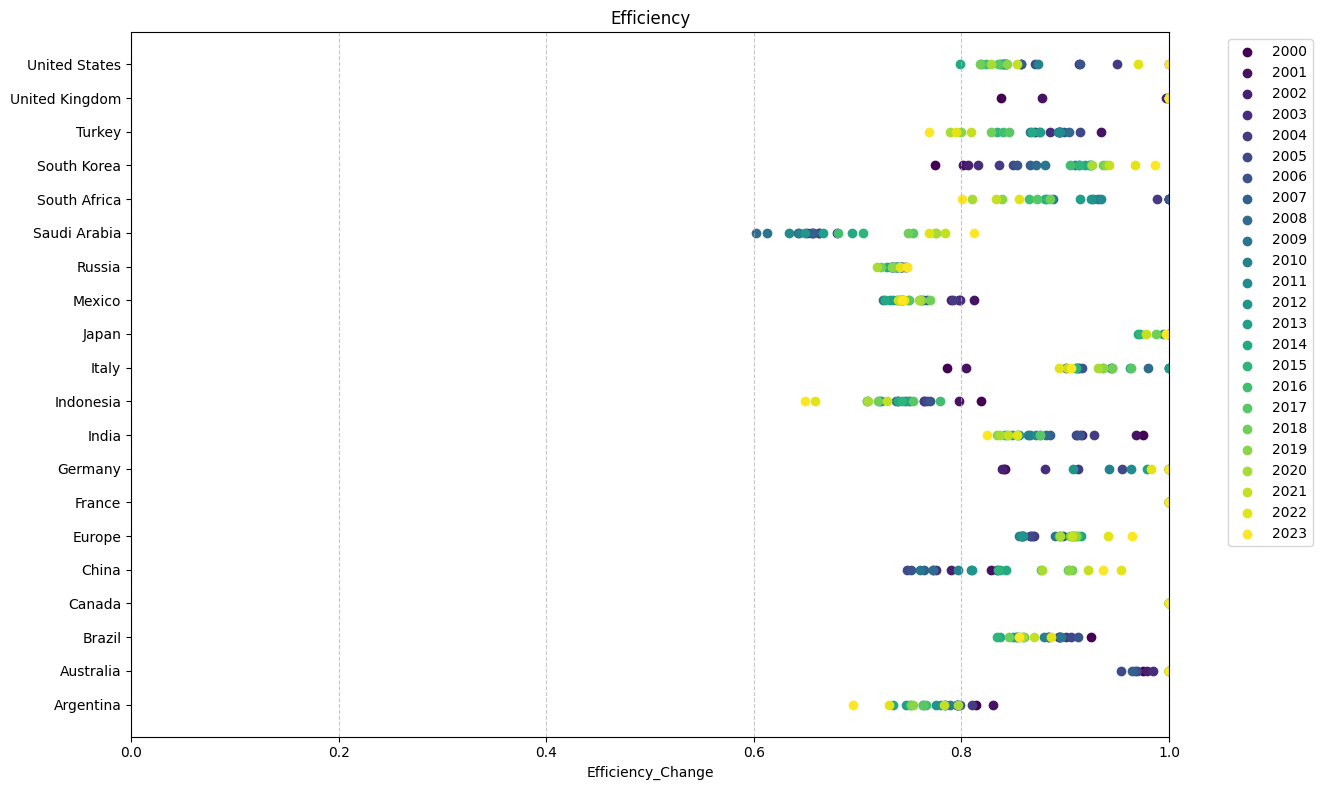

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))
years = list(range(year_start, year_end))
cmap = plt.cm.viridis
norm = plt.Normalize(min(years), max(years))

for year in range(year_start,year_end):

  print ("year", year)
  # Create the figure and ax  is

  # Plot the mean EC points
  print("results[year]")
  print (results[year])
  print("range")
  print(range(len(results)))

  print ("results[DMU]")
  print (results['DMU'])

  ax.scatter(results[year], range(len(results)), label=str(year), color=cmap(norm(year)))

  # Plot the confidence intervals
  #for idx, row in df4.iterrows():
  #    ax.hlines(y=df4.index.get_loc(idx),
  #              xmin=row['Eff_CI_Lower'],
  #              xmax=row['Eff_CI_Upper'],
  #              color='blue',
  #              alpha=0.3)

#Customize the plot
ax.set_yticks(range(len(results)))
ax.set_yticklabels(results['DMU'])
ax.set_xlabel('Efficiency_Change')
ax.set_title('Efficiency')

# Add a grid for better readability
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
ax.set_xlim(0,1)
# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(dir2write,"efficiency_plot.png"))
plt.show()